# Personal Protective Equipment (PPE) Detection using YOLOv8
## Dataset Description

The dataset contains **255 annotated images** divided into training, validation, and testing sets.

| Dataset Split | Images |
|--------------|-------:|
| Training | 179 |
| Validation | 49 |
| Testing | 27 |
| **Total** | **255** |

The dataset contains **11 object classes**:

1. Gloves
2. Goggles
3. Hardhat
4. Mask
5. NO-Gloves
6. NO-Goggles
7. NO-Hardhat
8. NO-Mask
9. NO-Safety Vest
10. Person
11. Safety Vest

These classes allow the model not only to detect workers but also to determine whether required PPE is present or missing.

This PPE detection system has several practical applications:

- Detects whether workers are wearing required safety equipment.
- Identifies missing protective equipment such as helmets, gloves, masks, goggles, and safety vests.
- Helps improve workplace safety by automatically monitoring PPE compliance.
- Can be integrated into CCTV surveillance systems for real-time safety monitoring.
- Reduces manual inspection effort and improves operational efficiency.

In [ ]:
!pip install ultralytics roboflow -q


**Dataset from roboflow for PPE Detection**

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="YTdm**************")
project = rf.workspace("yareds-workspace-vplqp").project("ppe-tesis-hmou9")
dataset = project.version(1).download("yolov8")

DATA_YAML = dataset.location + "/data.yaml"
print("Dataset ready:", dataset.location)


loading Roboflow workspace...
loading Roboflow project...
Dataset ready: /content/PPE-TESIS--1


**Check Dataset**

In [ ]:
import yaml, os

with open(DATA_YAML) as f:
    info = yaml.safe_load(f)

print("Classes :", info["nc"])
print("Names   :", info["names"])

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(dataset.location, split, "images")
    if os.path.exists(img_dir):
        n = len(os.listdir(img_dir))
        print(f"{split:6s}: {n} images")


Classes : 11
Names   : ['Gloves', 'Goggles', 'Hardhat', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Vest']
train : 179 images
valid : 49 images
test  : 27 images


**Preview dataset with ground truth box**

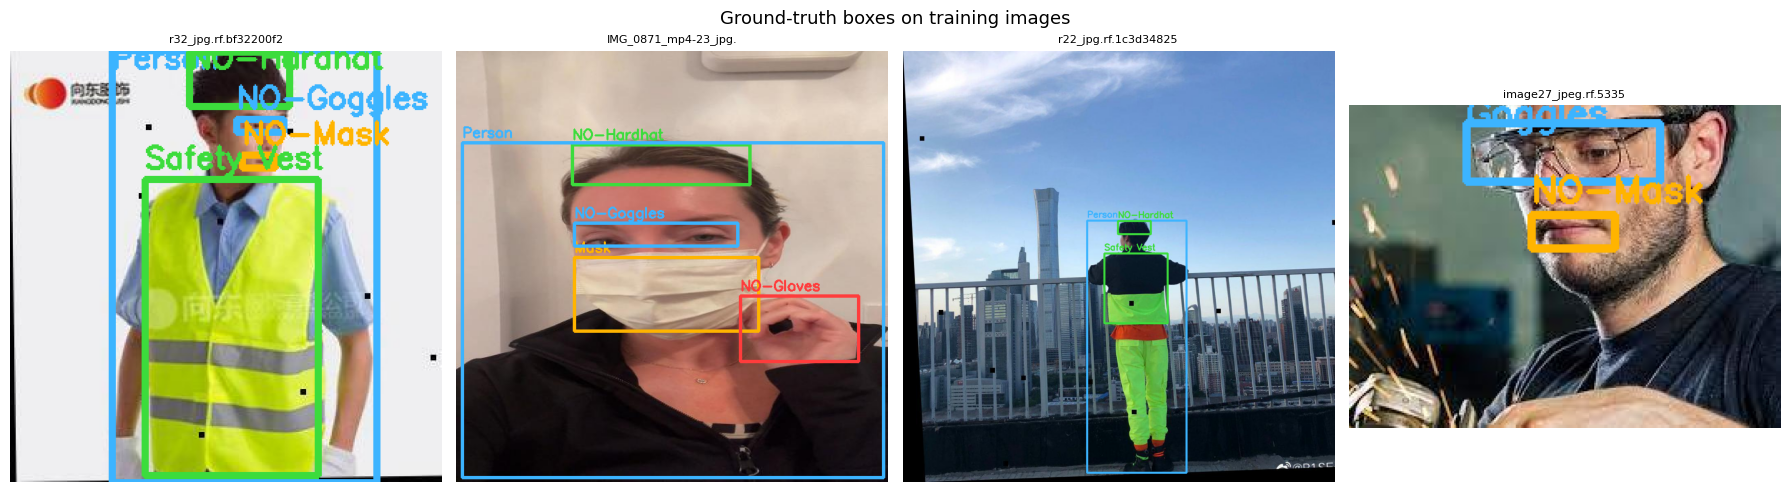

In [ ]:
import cv2, random, matplotlib.pyplot as plt

def draw_boxes(img_path, lbl_path, names):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    colors = [(255,60,60),(60,180,255),(60,220,60),(255,180,0)]
    if os.path.exists(lbl_path):
        for line in open(lbl_path):
            p = line.strip().split()
            if not p: continue
            c, xc, yc, bw, bh = int(p[0]), *map(float, p[1:5])
            x1,y1 = int((xc-bw/2)*w), int((yc-bh/2)*h)
            x2,y2 = int((xc+bw/2)*w), int((yc+bh/2)*h)
            col = colors[c % len(colors)]
            cv2.rectangle(img,(x1,y1),(x2,y2),col,3)
            cv2.putText(img, names[c],(x1,max(y1-8,12)),
                        cv2.FONT_HERSHEY_SIMPLEX,0.7,col,2)
    return img

img_dir = os.path.join(dataset.location, "train", "images")
lbl_dir = os.path.join(dataset.location, "train", "labels")
files   = random.sample(os.listdir(img_dir), min(4, len(os.listdir(img_dir))))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, fname in zip(axes, files):
    stem = fname.rsplit(".", 1)[0]
    img  = draw_boxes(f"{img_dir}/{fname}", f"{lbl_dir}/{stem}.txt", info["names"])
    ax.imshow(img); ax.axis("off"); ax.set_title(fname[:20], fontsize=8)
plt.suptitle("Ground-truth boxes on training images", fontsize=13)
plt.tight_layout(); plt.show()


**Fine tune COCO pretrained YOLOv8**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data      = DATA_YAML,
    epochs    = 50,
    imgsz     = 640,
    batch     = 16,
    patience  = 15,
    optimizer = "SGD",
    lr0       = 0.01,
    project   = "runs/ppe",
    name      = "yolov8n_finetune",
    pretrained= True,
    plots     = True,
)


Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PPE-TESIS--1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_finetune-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=

**Training Graphs**

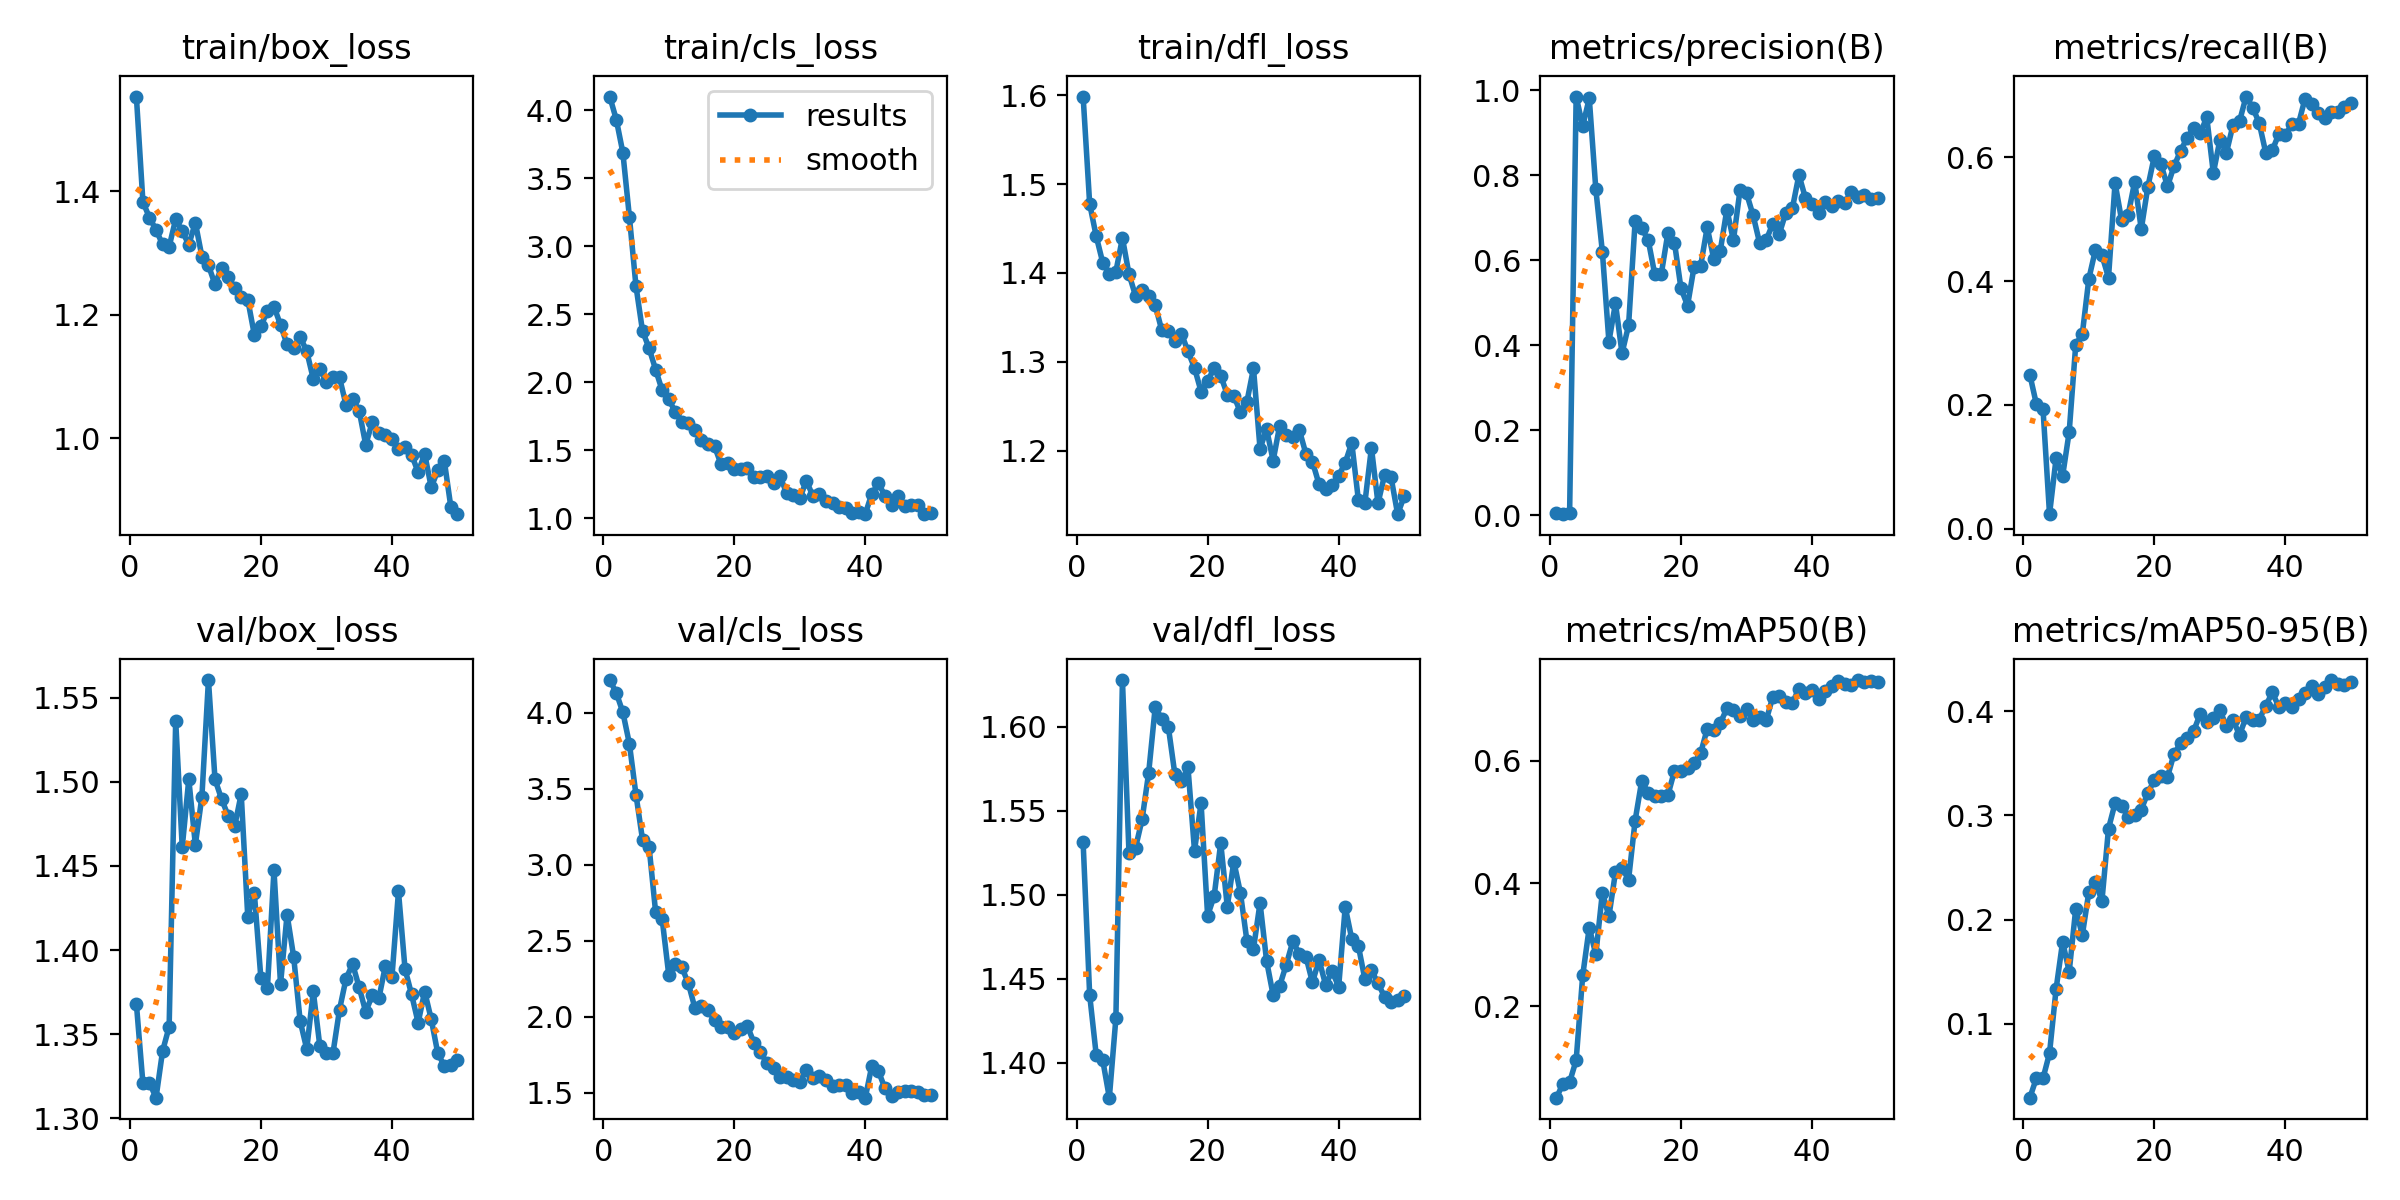

In [ ]:
from IPython.display import Image, display

curve = f"{results.save_dir}/results.png"
display(Image(filename=curve, width=850))


**Evaluation in Validation set**

In [ ]:
metrics = model.val(data=DATA_YAML, split="val")

print(f"Precision    : {metrics.box.mp:.4f}")
print(f"Recall       : {metrics.box.mr:.4f}")
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")


Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1782.4±1454.2 MB/s, size: 202.7 KB)
val: Scanning /content/PPE-TESIS--1/valid/labels.cache... 49 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 12.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.7s
                   all         49        315      0.748       0.67      0.732      0.431
                Gloves         10         19       0.52      0.343      0.338       0.19
               Goggles          9          9      0.807      0.778      0.939      0.528
               Hardhat         12         17      0.563          1      0.835      0.542
                  Mask          9          9      0.943      0.778      0.838      0.546
             NO-Gloves         25         59   

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "class" : info["names"][:len(metrics.box.ap50)],
    "AP@0.5": [round(v, 4) for v in metrics.box.ap50],
})
print(df.sort_values("AP@0.5", ascending=False).to_string(index=False))


         class  AP@0.5
       Goggles  0.9392
        Person  0.8943
   Safety Vest  0.8523
          Mask  0.8379
       Hardhat  0.8351
       NO-Mask  0.8114
    NO-Goggles  0.7318
    NO-Hardhat  0.7314
     NO-Gloves  0.6795
NO-Safety Vest  0.4016
        Gloves  0.3378


── confusion_matrix.png ──


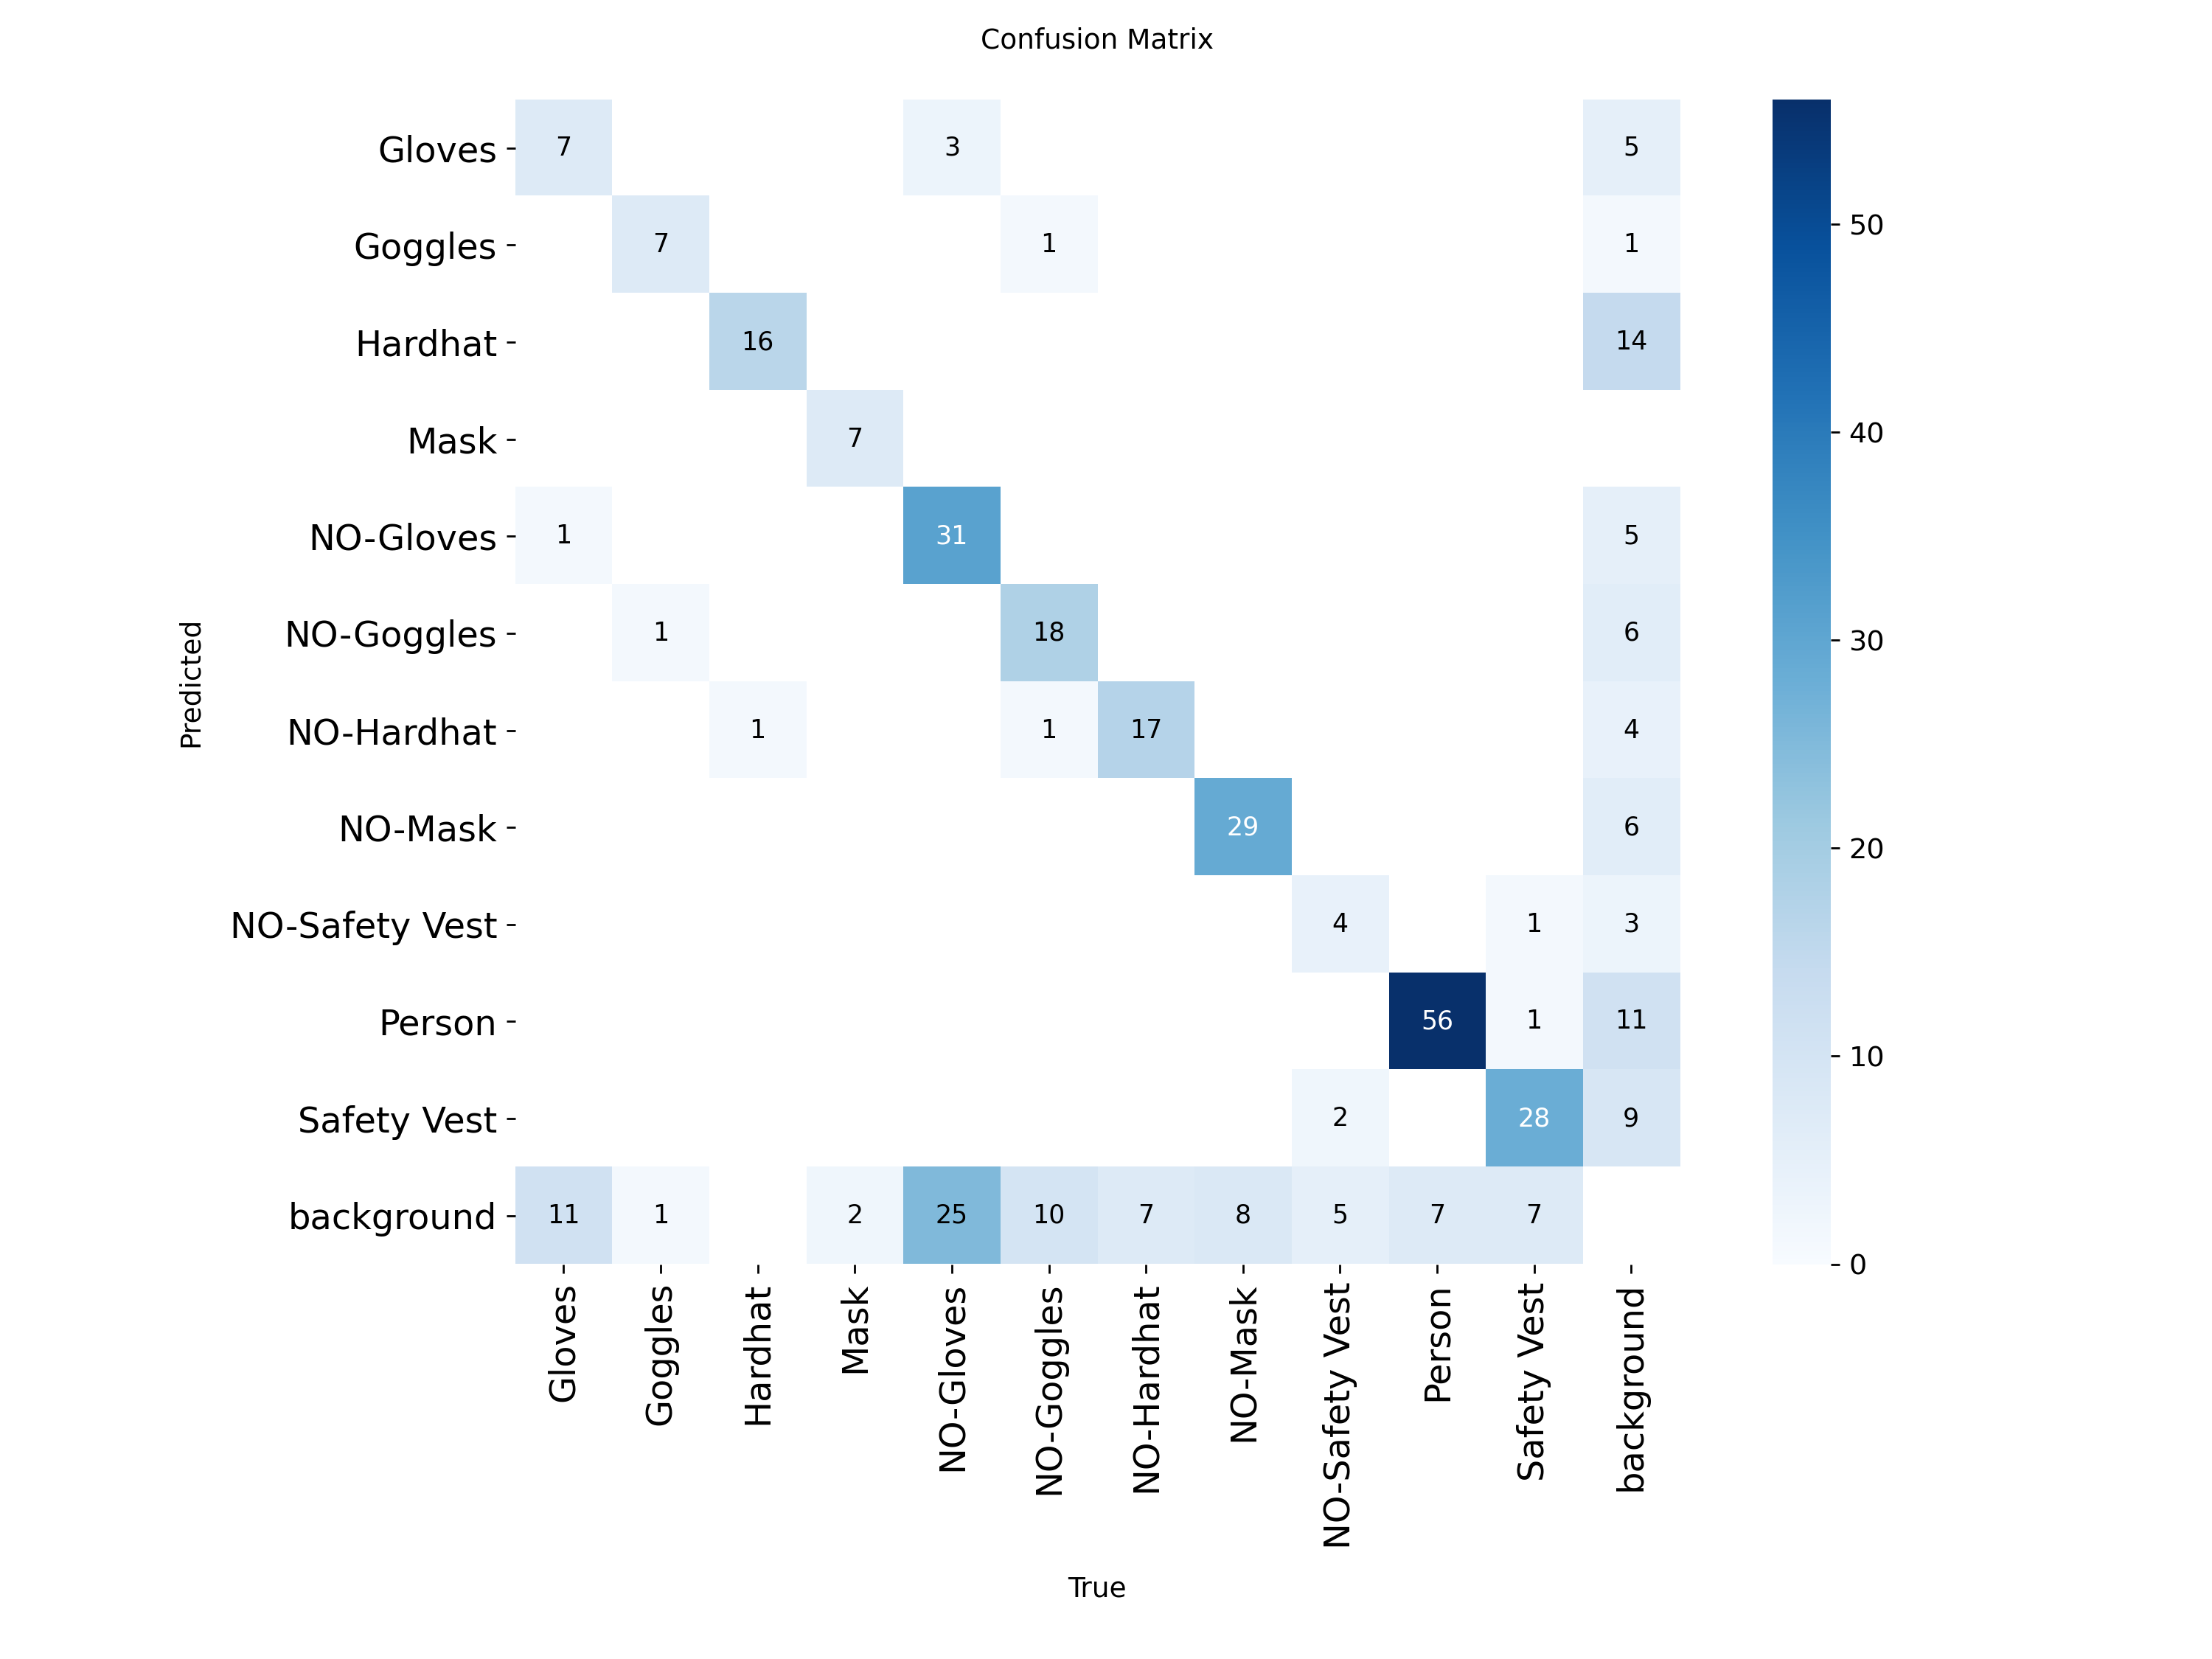

In [ ]:
val_dir = str(metrics.save_dir)
for fname in ["confusion_matrix.png", "PR_curve.png"]:
    path = f"{val_dir}/{fname}"
    if os.path.exists(path):
        print(f"── {fname} ──")
        display(Image(filename=path, width=650))


**Run Prediction on Test Images**  


0: 416x416 2 Hardhats, 1 NO-Goggles, 1 NO-Mask, 1 NO-Safety Vest, 1 Person, 3.1ms
1: 416x416 1 Mask, 1 NO-Goggles, 1 NO-Hardhat, 1 Person, 3.1ms
2: 416x416 1 NO-Goggles, 1 NO-Hardhat, 1 NO-Mask, 1 Person, 1 Safety Vest, 3.1ms
3: 416x416 5 Hardhats, 1 NO-Mask, 2 Persons, 5 Safety Vests, 3.1ms
Speed: 1.5ms preprocess, 3.1ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 416)


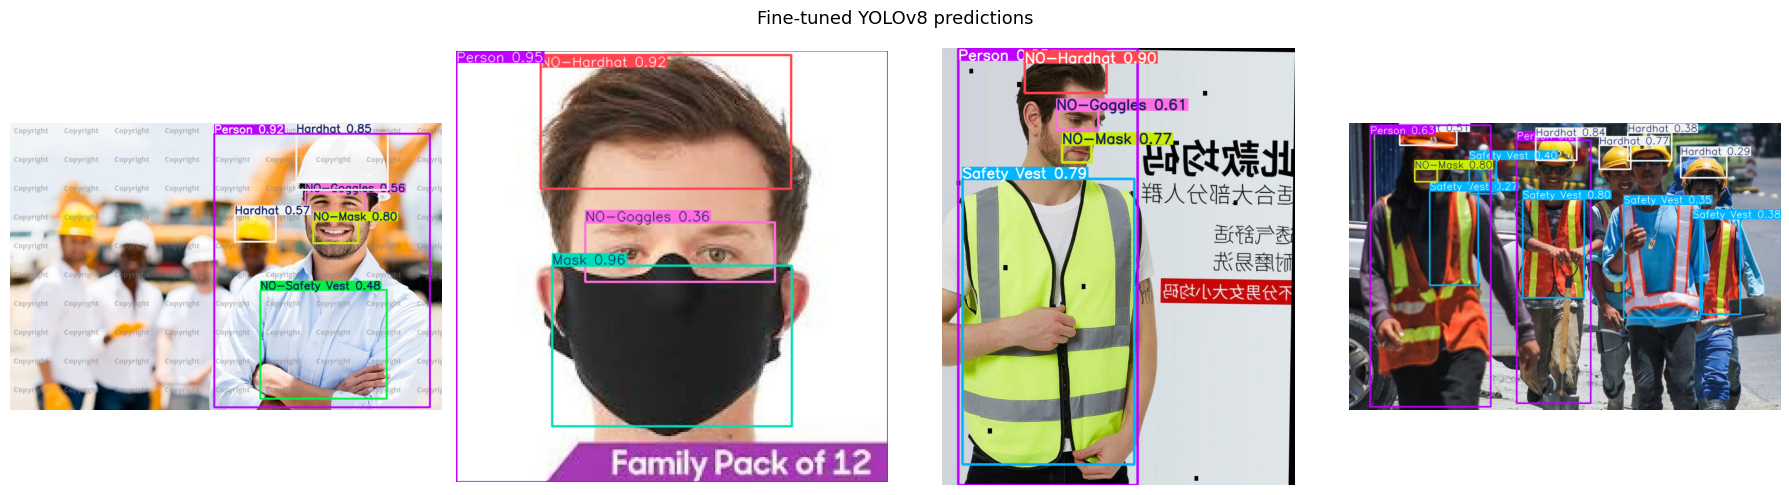

In [ ]:
test_img_dir = os.path.join(dataset.location, "test", "images")
test_imgs    = [f"{test_img_dir}/{f}" for f in os.listdir(test_img_dir)][:4]

preds = model.predict(source=test_imgs, conf=0.25, imgsz=416)

fig, axes = plt.subplots(1, len(preds), figsize=(18, 5))
axes = axes if len(preds) > 1 else [axes]
for ax, r in zip(axes, preds):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.suptitle("Fine-tuned YOLOv8 predictions", fontsize=13)
plt.tight_layout(); plt.show()
